<a href="https://colab.research.google.com/github/laboralit82-lab/AprendizajeAutomatico1/blob/main/Mariela%20Malizia_Introduccion_Regresion_Lineal_sklearn_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AA1 Introducción a la Regresión Lineal con Scikit-Learn

¡Bienvenido/a! En este tutorial vas a aprender, paso a paso, cómo construir tu primer modelo de **Regresión Lineal** usando la librería `scikit-learn` de Python.

### ¿Qué vas a aprender?
1. Qué es la regresión lineal y para qué sirve
2. Cómo explorar y visualizar un dataset
3. Cómo dividir los datos en entrenamiento y prueba
4. Cómo entrenar un modelo de regresión lineal
5. Cómo evaluar qué tan bueno es el modelo
6. Cómo hacer predicciones con datos nuevos
7. Regresión lineal múltiple (bonus)
8. Ejercicios para practicar
9. Cuándo (y cuándo no) escalar variables con `StandardScaler`

> 💡 **Tip:** Ejecutá las celdas en orden, de arriba hacia abajo, usando `Shift + Enter`. Si te trabás en algún ejercicio, no hay problema, ¡es parte de aprender!

---


## 1. ¿Qué es la regresión lineal?

La **regresión lineal** es uno de los algoritmos más simples y fundamentales del Machine Learning. Se usa cuando queremos **predecir un valor numérico continuo** (por ejemplo: un precio, una temperatura, un puntaje) a partir de una o más variables.

La idea central es encontrar la **línea recta** (o el hiperplano, si hay más de una variable) que mejor se ajusta a los datos:

$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \varepsilon $$

Donde:
- $y$ es la variable que queremos predecir (variable dependiente)
- $x_1, x_2, ..., x_n$ son las variables que usamos para predecir (variables independientes)
- $\beta_0$ es la ordenada al origen (intercepto)
- $\beta_1, ..., \beta_n$ son los coeficientes (pendientes)
- $\varepsilon$ es el error

**Ejemplo cotidiano:** predecir el precio de una casa a partir de sus metros cuadrados.


## 2. Importar las librerías necesarias

Vamos a usar:
- `numpy` y `pandas` para manejar los datos
- `matplotlib` para graficar
- `scikit-learn` para el modelo de Machine Learning

Estas librerías ya vienen instaladas en Google Colab, así que no hace falta instalar nada.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Para que los gráficos se vean prolijos
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


## 3. Nuestro dataset: horas de estudio vs. calificación

Para empezar de forma simple, vamos a trabajar con un dataset **sintético** (inventado, pero realista) que relaciona las **horas de estudio** de un grupo de estudiantes con la **calificación** que obtuvieron en un examen (sobre 100 puntos).

Generamos los datos con un poco de ruido aleatorio para simular la variabilidad del mundo real.


In [ ]:
# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(1357)

# Generamos 60 estudiantes con horas de estudio entre 0 y 10
horas_estudio = np.random.uniform(0, 10, 60)

# La calificación depende linealmente de las horas de estudio, más un poco de ruido
ruido = np.random.normal(0, 6, 60)
calificacion = 35 + 6.2 * horas_estudio + ruido
calificacion = np.clip(calificacion, 0, 100)  # las notas van de 0 a 100

# Armamos un DataFrame de pandas (más cómodo para trabajar)
df = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'calificacion': calificacion
})

df.head()


,horas_estudio,calificacion
0,1.424301,44.770077
1,7.478109,75.726351
2,3.804269,58.356380
3,9.797378,93.760481
4,5.471555,74.530331


### 3.1 Explorando los datos

Antes de entrenar cualquier modelo, siempre conviene **mirar los datos**: cuántas filas hay, si hay valores faltantes, cómo se distribuyen las variables, etc.


In [ ]:
print("Cantidad de filas y columnas:", df.shape)
print("\nInformación general:")
df.info()


Cantidad de filas y columnas: (60, 2)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   horas_estudio  60 non-null     float64
 1   calificacion   60 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


In [ ]:
df.describe()


,horas_estudio,calificacion
count,60.000000,60.000000
mean,5.505362,69.560829
std,2.889137,18.408391
min,0.657296,35.087158
25%,2.929498,54.053687
50%,5.347302,72.883413
75%,8.391026,84.868611
max,9.818994,97.952631


### 3.2 Visualizando la relación entre las variables

Un gráfico de dispersión (*scatter plot*) nos permite ver rápidamente si existe una relación lineal entre las dos variables.


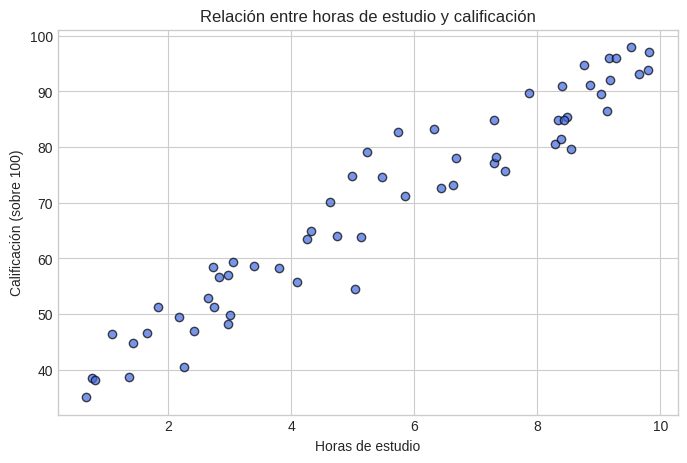

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['horas_estudio'], df['calificacion'], color='royalblue', alpha=0.7, edgecolor='k')
plt.xlabel('Horas de estudio')
plt.ylabel('Calificación (sobre 100)')
plt.title('Relación entre horas de estudio y calificación')
plt.show()


**Pregunta para pensar:** 🤔 ¿Te parece que hay una relación lineal (aproximadamente una línea recta) entre las horas de estudio y la calificación?


## 4. Dividir los datos: entrenamiento y prueba

Un paso **fundamental** en Machine Learning es dividir los datos en dos conjuntos:

- **Entrenamiento (train):** los datos que el modelo va a "ver" para aprender el patrón.
- **Prueba (test):** los datos que el modelo NO va a ver durante el entrenamiento, y que usamos después para evaluar qué tan bien generaliza a datos nuevos.

Esto es crucial porque si evaluamos el modelo con los mismos datos que usamos para entrenarlo, no sabemos realmente qué tan bien va a funcionar con información nueva (esto se llama **overfitting** o sobreajuste).

Usamos la función `train_test_split` de scikit-learn, reservando un 20% de los datos para prueba.


In [ ]:
# X debe ser una matriz 2D (filas = muestras, columnas = features), por eso usamos [['horas_estudio']]
X = df[['horas_estudio']]
y = df['calificacion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])


Datos de entrenamiento: 48
Datos de prueba: 12


In [ ]:
X_train.shape

(48, 1)

## 5. Entrenar el modelo de regresión lineal

Con scikit-learn, entrenar un modelo se resume en 3 pasos, siempre iguales para (casi) cualquier algoritmo:

1. **Crear** el modelo: `modelo = LinearRegression()`
2. **Entrenar** (ajustar) el modelo con los datos de entrenamiento: `modelo.fit(X_train, y_train)`
3. **Predecir** con datos nuevos: `modelo.predict(X_nuevo)`


In [ ]:
# 1. Crear el modelo
modelo = LinearRegression()

# 2. Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("¡Modelo entrenado!")


¡Modelo entrenado!


### 5.1 Los coeficientes del modelo

Una vez entrenado, el modelo aprendió los valores de $\beta_0$ (intercepto) y $\beta_1$ (pendiente) que mejor ajustan la recta a los datos de entrenamiento.


In [ ]:
modelo.intercept_

np.float64(34.95833956884839)

In [ ]:
modelo.coef_

array([6.13644466])

In [ ]:
intercepto = modelo.intercept_
pendiente = modelo.coef_[0]

print(f"Intercepto (β0): {intercepto:.2f}")
print(f"Pendiente  (β1): {pendiente:.2f}")
print(f"\nLa ecuación aprendida es aproximadamente:")
print(f"calificacion = {intercepto:.2f} + {pendiente:.2f} * horas_estudio")


Intercepto (β0): 34.96
Pendiente  (β1): 6.14

La ecuación aprendida es aproximadamente:
calificacion = 34.96 + 6.14 * horas_estudio


**Interpretación:** por cada hora extra de estudio, la calificación esperada aumenta en aproximadamente el valor de la pendiente (β1) puntos.


## 6. Visualizar la recta de regresión

Grafiquemos los datos de entrenamiento junto con la recta que aprendió el modelo.


In [ ]:
modelo.predict(X_train)

array([48.31055807, 95.0794096 , 74.40075556, 70.18101668, 49.80894444,
       86.11208598, 88.65264896, 68.53423197, 51.16073676, 86.45622682,
       91.27495434, 90.36378038, 86.44713406, 75.61229521, 94.13506511,
       87.3870873 , 91.17344738, 53.43009788, 46.15487894, 38.9917999 ,
       61.05633353, 48.75947503, 61.48797008, 39.91436664, 79.88433869,
       86.71650123, 66.44332228, 43.29846104, 53.67158517, 80.84734256,
       45.06017978, 58.30302429, 60.03934829, 90.97842866, 53.1695969 ,
       65.89337781, 79.72290626, 86.99529343, 89.2902578 , 51.79352056,
       93.39839339, 70.8466361 , 52.30354848, 75.91163118, 85.75964528,
       39.64694184, 63.32382335, 73.6947591 ])

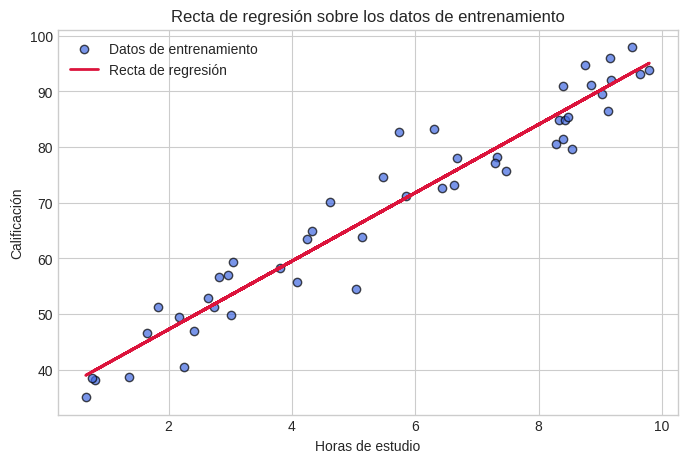

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='royalblue', alpha=0.7, edgecolor='k', label='Datos de entrenamiento')
plt.plot(X_train, modelo.predict(X_train), color='crimson', linewidth=2, label='Recta de regresión')
plt.xlabel('Horas de estudio')
plt.ylabel('Calificación')
plt.title('Recta de regresión sobre los datos de entrenamiento')
plt.legend()
plt.show()


## 7. Evaluar el modelo con los datos de prueba

Ahora viene el momento de la verdad: usamos el modelo para predecir sobre los datos de **prueba** (que el modelo nunca vio) y comparamos esas predicciones con los valores reales.

Las métricas más comunes para regresión son:

- **MAE (Error Absoluto Medio):** el promedio de cuánto se equivoca el modelo, en las mismas unidades que la variable objetivo.
- **MSE (Error Cuadrático Medio):** similar, pero penaliza más los errores grandes.
- **RMSE (Raíz del MSE):** como el MSE, pero en las unidades originales (más fácil de interpretar).
- **R² (Coeficiente de determinación):** indica qué porcentaje de la variabilidad de los datos explica el modelo. Va de 0 a 1 (más cerca de 1 es mejor).


In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Error Absoluto Medio):     {mae:.2f}")
print(f"MSE  (Error Cuadrático Medio):   {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático):{rmse:.2f}")
print(f"R²   (Coef. de determinación):   {r2:.2f}")


MAE  (Error Absoluto Medio):     4.95
MSE  (Error Cuadrático Medio):   35.15
RMSE (Raíz del Error Cuadrático):5.93
R²   (Coef. de determinación):   0.90


### 7.1 Predicciones vs. valores reales

Otra forma útil de ver el desempeño del modelo es comparar visualmente las predicciones contra los valores reales. Si el modelo fuera perfecto, todos los puntos caerían sobre la línea diagonal.


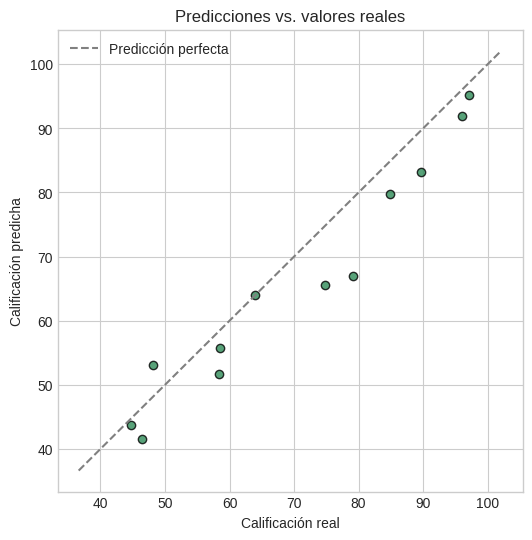

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='seagreen', alpha=0.8, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()) - 5, max(y_test.max(), y_pred.max()) + 5]
plt.plot(lims, lims, color='gray', linestyle='--', label='Predicción perfecta')
plt.xlabel('Calificación real')
plt.ylabel('Calificación predicha')
plt.title('Predicciones vs. valores reales')
plt.legend()
plt.show()


## 8. Hacer una predicción con un dato nuevo

Ahora que el modelo está entrenado, podemos usarlo para predecir la calificación de un estudiante nuevo, dado el número de horas que estudió.


In [ ]:
horas_nuevas = pd.DataFrame({'horas_estudio': [3.5, 7, 9.5]})
predicciones_nuevas = modelo.predict(horas_nuevas)

for horas, pred in zip(horas_nuevas['horas_estudio'], predicciones_nuevas):
    print(f"Si estudia {horas} horas, se predice una calificación de {pred:.1f} puntos")


Si estudia 3.5 horas, se predice una calificación de 56.4 puntos
Si estudia 7.0 horas, se predice una calificación de 77.9 puntos
Si estudia 9.5 horas, se predice una calificación de 93.3 puntos


## 9. Regresión lineal múltiple

Hasta ahora usamos **una sola variable** (horas de estudio) para predecir la calificación. Pero en la práctica, casi siempre tenemos **varias variables** que pueden influir en el resultado. A esto se lo llama **regresión lineal múltiple**.

Agreguemos una segunda variable: la cantidad de **horas de sueño** la noche anterior al examen.


In [ ]:
np.random.seed(1)

horas_sueño = np.random.uniform(3, 9, 60)
ruido2 = np.random.normal(0, 10, 60)
ruido2



array([ -1.91835552,  -8.87628964,  -7.47158294,  16.92454601,
         0.50807755,  -6.36995647,   1.90915485,  21.00255136,
         1.20158952,   6.1720311 ,   3.0017032 ,  -3.52249846,
       -11.42518198,  -3.49342722,  -2.08894233,   5.86623191,
         8.38983414,   9.31102081,   2.85587325,   8.85141164,
        -7.54397941,  12.52868155,   5.1292982 ,  -2.98092835,
         4.88518147,  -0.75571713,  11.31629387,  15.19816816,
        21.85575407, -13.96496335, -14.44113805,  -5.04465863,
         1.60037069,   8.76168921,   3.15634947, -20.22201216,
        -3.06204013,   8.27974643,   2.30094735,   7.6201118 ,
        -2.22328143,  -2.00758069,   1.86561391,   4.10051647,
         1.9829972 ,   1.19008646,  -6.70662286,   3.77563786,
         1.21821271,  11.29483908,  11.9891788 ,   1.85156417,
        -3.7528495 ,  -6.38730407,   4.23494354,   0.77340068,
        -3.43853676,   0.43596857,  -6.20000844,   6.98032034])

In [ ]:
# Ahora la calificación depende de las horas de estudio Y de las horas de sueño
calificacion_multi = 20 + 5.5 * horas_estudio + 3.0 * horas_sueño + ruido2
calificacion_multi = np.clip(calificacion_multi, 0, 100)

df_multi = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'horas_sueño': horas_sueño,
    'calificacion': calificacion_multi
})

df_multi.head()

,horas_estudio,horas_sueño,calificacion
0,1.424301,5.502132,42.421698
1,7.478109,7.321947,74.219152
2,3.804269,3.000686,42.453954
3,9.797378,4.813995,100.000000
4,5.471555,3.880535,62.243234


In [ ]:
# El proceso es exactamente el mismo, solo que ahora X tiene dos columnas
X_multi = df_multi[['horas_estudio', 'horas_sueño']]
y_multi = df_multi['calificacion']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

print("Intercepto:", round(modelo_multi.intercept_, 2))
print("Coeficientes:", dict(zip(X_multi.columns, modelo_multi.coef_.round(2))))

y_pred_m = modelo_multi.predict(X_test_m)
print("\nR² en test:", round(r2_score(y_test_m, y_pred_m), 2))


Intercepto: 24.21
Coeficientes: {'horas_estudio': np.float64(5.6), 'horas_sueño': np.float64(2.51)}

R² en test: 0.88


**Interpretación:** cada coeficiente indica cuánto cambia la calificación esperada por cada unidad extra de esa variable, **manteniendo constante** la otra variable.


## 10. 🏋️ Ejercicios para practicar

Completá las siguientes celdas de código (reemplazá `# TU CÓDIGO AQUÍ` por tu solución). ¡No hay una sola forma correcta de hacerlo, lo importante es que llegues al resultado!

### Ejercicio 1
Calculá cuál sería la calificación predicha para un estudiante que estudió **6.5 horas** usando el modelo simple (`modelo`, el de una sola variable).


In [58]:
# Ejercicio 1
# TU CÓDIGO AQUÍ
# Ejercicio 1

horas = [[6.5]]
calificacion_predicha = modelo.predict(horas)

print("Calificación predicha:", calificacion_predicha[0])


Calificación predicha: 74.84522987421818


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Ejercicio 2
Usando el dataset original (`df`), calculá la correlación entre `horas_estudio` y `calificacion` con el método `.corr()` de pandas. ¿Qué tan fuerte te parece la relación?

*Pista: `df['col1'].corr(df['col2'])`*


In [59]:
# Ejercicio 2
# TU CÓDIGO AQUÍ
# Ejercicio 2

correlacion = df['horas_estudio'].corr(df['calificacion'])

print("Correlación:", correlacion)

Correlación: 0.964023394710226


La correlación obtenida es de aproximadamente 0,96, lo que indica una relación positiva muy fuerte entre las horas de estudio y la calificación. Esto significa que, en general, a medida que aumentan las horas de estudio, también tiende a aumentar la calificación.

### Ejercicio 3
Entrená un nuevo modelo (`modelo_ej3`) cambiando el `test_size` a `0.3` (30% de los datos para prueba) en lugar de 0.2. Calculá el R² sobre el nuevo conjunto de prueba y compará con el modelo original. ¿Cambió mucho el resultado?


In [60]:
# Ejercicio 3
# TU CÓDIGO AQUÍ
# Ejercicio 3

# Nueva división: 30% para prueba
X_train_ej3, X_test_ej3, y_train_ej3, y_test_ej3 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Crear y entrenar el nuevo modelo
modelo_ej3 = LinearRegression()
modelo_ej3.fit(X_train_ej3, y_train_ej3)

# Calcular R² del nuevo modelo
r2_ej3 = modelo_ej3.score(X_test_ej3, y_test_ej3)

# Comparar con el modelo original
r2_original = modelo.score(X_test, y_test)

print("R² modelo original (20%):", r2_original)
print("R² nuevo modelo (30%):", r2_ej3)

R² modelo original (20%): 0.8971028990732178
R² nuevo modelo (30%): 0.8981228638869224


Al aumentar el conjunto de prueba del 20% al 30%, el R² pasó de 0,897 a 0,898. El resultado prácticamente no cambió, por lo que el modelo mantiene un rendimiento muy similar con ambas divisiones de los datos.

### Ejercicio 4 (desafío)
Agregá una tercera variable al dataset de regresión múltiple, por ejemplo `horas_de_celular` (inventada, con `np.random.uniform`), donde a **más** horas de celular, la calificación tienda a **bajar** (coeficiente negativo). Entrená un modelo con las tres variables y observá los coeficientes obtenidos.


In [61]:
# Ejercicio 4
# TU CÓDIGO AQUÍ
# Ejercicio 4

# Hacemos una copia para no modificar el dataset original
df_ej4 = df_multi.copy()

# Crear la tercera variable: horas de celular
np.random.seed(42)
df_ej4['horas_de_celular'] = np.random.uniform(1, 8, len(df_ej4))

# Hacer que a más horas de celular, la calificación tienda a bajar
df_ej4['calificacion'] = (
    df_ej4['calificacion'] - 2 * df_ej4['horas_de_celular']
)

# Definir las tres variables predictoras
X_multi_3 = df_ej4[
    ['horas_estudio', 'horas_sueño', 'horas_de_celular']
]
y_multi_3 = df_ej4['calificacion']

# Dividir los datos
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_multi_3, y_multi_3, test_size=0.2, random_state=42
)

# Entrenar el modelo
modelo_3 = LinearRegression()
modelo_3.fit(X_train_3, y_train_3)

# Mostrar los coeficientes
for variable, coeficiente in zip(X_multi_3.columns, modelo_3.coef_):
    print(variable, ":", coeficiente)


horas_estudio : 5.585379347341466
horas_sueño : 2.4741288998526283
horas_de_celular : -4.426299262496766


Los coeficientes muestran que las horas de estudio y las horas de sueño tienen una relación positiva con la calificación. En cambio, las horas de celular presentan un coeficiente negativo (−4,43), indicando que, a medida que aumentan las horas de uso del celular, la calificación tiende a disminuir.

## 11. ¿Hace falta escalar las variables? (`StandardScaler`)

Quizás te preguntaste por qué en todo el tutorial nunca usamos `StandardScaler` para escalar `X_train` y `X_test` antes de entrenar. La respuesta corta es: **en regresión lineal simple/múltiple (OLS), no hace falta**. Vamos a comprobarlo con código, y después vamos a ver un caso donde el escalado **sí importa**.

### 11.1 La regresión lineal da el mismo resultado con o sin escalar

La regresión lineal resuelve el problema de forma analítica (no usa gradiente descendente), así que escalar una variable simplemente reescala su coeficiente de forma proporcional e inversa. Las predicciones finales y las métricas (R², MAE, etc.) **no cambian**.


In [ ]:
from sklearn.preprocessing import StandardScaler

# --- Modelo SIN escalar (el mismo que ya entrenamos) ---
modelo_sin_escalar = LinearRegression()
modelo_sin_escalar.fit(X_train, y_train)
r2_sin_escalar = r2_score(y_test, modelo_sin_escalar.predict(X_test))

# --- Modelo CON escalado ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # ajustamos el scaler SOLO con train
X_test_scaled = scaler.transform(X_test)         # aplicamos la misma transformación a test

modelo_escalado = LinearRegression()
modelo_escalado.fit(X_train_scaled, y_train)
r2_escalado = r2_score(y_test, modelo_escalado.predict(X_test_scaled))

print(f"R² sin escalar: {r2_sin_escalar:.6f}")
print(f"R² escalado:    {r2_escalado:.6f}")
print(f"\n¿Son (casi) iguales? {np.isclose(r2_sin_escalar, r2_escalado)}")


R² sin escalar: 0.897103
R² escalado:    0.897103

¿Son (casi) iguales? True


**IMPORTANTISIMO!!!!!**

⚠️ **Detalle importante sobre buenas prácticas:** fijate que en el código de arriba ajustamos (`fit_transform`) el `StandardScaler` **solo con los datos de entrenamiento**, y luego usamos `transform` (sin `fit`) sobre los datos de test. Esto es clave para evitar **data leakage** (fuga de información): si "mirásemos" los datos de test para calcular la media y el desvío del escalado, estaríamos filtrando información del futuro hacia el entrenamiento, y eso haría que la evaluación del modelo sea artificialmente optimista.

Esta misma regla aplica siempre que uses cualquier transformación (escalado, imputación de nulos, codificación de variables categóricas, etc.): **se ajusta con train, se aplica a train y a test**.


### 11.2 ¿Cuándo SÍ importa escalar? Introducción a la regularización (Ridge y Lasso)

Antes de ver el ejemplo, hagamos una breve introducción a un concepto nuevo: la **regularización**.

#### ¿Qué problema resuelve la regularización?

Cuando un modelo de regresión lineal tiene muchas variables (o variables muy correlacionadas entre sí), puede terminar **sobreajustándose** (*overfitting*): ajusta demasiado bien los datos de entrenamiento, aprendiendo hasta el ruido, y generaliza mal a datos nuevos. Esto suele verse como coeficientes ($\beta$) muy grandes o inestables.

La regularización soluciona esto agregando una **penalización** a la función de costo que el modelo minimiza. En lugar de buscar únicamente los coeficientes que minimizan el error sobre los datos de entrenamiento, el modelo busca un equilibrio entre:

1. Ajustar bien los datos (error bajo)
2. Mantener los coeficientes lo más pequeños posible

$$ \text{Costo} = \underbrace{\sum (y_i - \hat{y}_i)^2}_{\text{error de ajuste}} + \underbrace{\alpha \cdot \text{penalización}}_{\text{regularización}} $$

El hiperparámetro $\alpha$ (alpha) controla cuánto peso le damos a la penalización: con $\alpha = 0$ es una regresión lineal común; a medida que $\alpha$ crece, los coeficientes se "encogen" cada vez más hacia cero.

#### Ridge (regularización L2)

`Ridge` penaliza la **suma de los cuadrados** de los coeficientes:

$$ \text{penalización}_{Ridge} = \sum \beta_j^2 $$

Esto hace que los coeficientes se achiquen de forma suave, pero **rara vez llegan a valer exactamente cero**. Es útil cuando creemos que todas las variables aportan algo, pero queremos evitar coeficientes exageradamente grandes.

#### Lasso (regularización L1)

`Lasso` penaliza la **suma del valor absoluto** de los coeficientes:

$$ \text{penalización}_{Lasso} = \sum |\beta_j| $$

Esto tiene una propiedad especial: puede llevar coeficientes **exactamente a cero**, eliminando variables poco relevantes del modelo. Por eso Lasso también sirve como una forma automática de **selección de variables**.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penaliza | Suma de cuadrados de los coeficientes | Suma de valores absolutos de los coeficientes |
| ¿Puede anular coeficientes (=0)? | No (los achica, pero no los anula) | Sí, puede eliminar variables |
| Útil cuando... | Todas las variables aportan algo | Sospechamos que algunas variables son irrelevantes |

#### ¿Qué tiene que ver esto con el escalado?

Acá está el punto clave: como la penalización actúa sobre la **magnitud** de los coeficientes, si dos variables están en escalas muy distintas (por ejemplo, horas de estudio de 0 a 10, e ingreso familiar de 0 a 5000), sus coeficientes también van a tener magnitudes muy distintas *aunque su importancia real sea similar*. La regularización terminaría penalizando de forma desigual, castigando más a la variable que "necesita" un coeficiente numéricamente más grande solo por estar en una escala más chica. Por eso, **antes de aplicar Ridge o Lasso, siempre conviene escalar las variables con `StandardScaler`**.

Veamos esto en código con el mismo ejemplo de horas de estudio e ingreso familiar.


### 11.3 Ejemplo en código: Ridge con y sin escalar

In [ ]:
from sklearn.linear_model import Ridge

np.random.seed(7)

ingreso_familiar = np.random.uniform(0, 5000, 60)   # escala mucho más grande
ruido3 = np.random.normal(0, 5, 60)

# La calificación depende un poco de ambas variables (coeficientes reales similares en magnitud "real")
calificacion_ridge = 30 + 5.0 * horas_estudio + 0.003 * ingreso_familiar + ruido3
calificacion_ridge = np.clip(calificacion_ridge, 0, 100)

df_ridge = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'ingreso_familiar': ingreso_familiar,
    'calificacion': calificacion_ridge
})

X_r = df_ridge[['horas_estudio', 'ingreso_familiar']]
y_r = df_ridge['calificacion']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)


In [ ]:
# --- Ridge SIN escalar ---
ridge_sin_escalar = Ridge(alpha=1.0)
ridge_sin_escalar.fit(X_train_r, y_train_r)

print("Ridge SIN escalar:")
print(dict(zip(X_r.columns, ridge_sin_escalar.coef_.round(5))))

# --- Ridge CON escalado ---
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

ridge_escalado = Ridge(alpha=1.0)
ridge_escalado.fit(X_train_r_scaled, y_train_r)

print("\nRidge CON escalado:")
print(dict(zip(X_r.columns, ridge_escalado.coef_.round(3))))


Ridge SIN escalar:
{'horas_estudio': np.float64(4.53787), 'ingreso_familiar': np.float64(0.00276)}

Ridge CON escalado:
{'horas_estudio': np.float64(12.779), 'ingreso_familiar': np.float64(3.489)}


**IMPORTANTISIMO!!!!!**

**¿Qué observás?** Sin escalar, el coeficiente de `ingreso_familiar` aparece como un número diminuto (porque la variable se mide en miles) y el de `horas_estudio` se ve mucho más grande — pero eso **no significa** que las horas de estudio importen más, solo que están en una escala distinta. Además, `Ridge` va a penalizar más fuerte al coeficiente que numéricamente es más grande, castigando de forma desigual a las variables según su escala y no según su verdadera importancia.

Con el escalado, ambas variables quedan con media 0 y desvío estándar 1, así que los coeficientes ya son **comparables entre sí** y la penalización de `Ridge` actúa de forma justa sobre ambas.

### 11.4 Conclusión práctica

El siguiente cuadro te resumen cuándo es importante escalar los datos previo al entrenamiento de algún modelo.

| Situación | ¿Necesita `StandardScaler`? |
|---|---|
| Regresión lineal simple/múltiple (`LinearRegression`) | No es necesario (aunque tampoco perjudica) |
| Ridge, Lasso, ElasticNet (regularización) | **Sí**, casi siempre |
| Comparar la "importancia" de coeficientes entre variables | **Sí** |
| KNN, SVM, redes neuronales, K-Means | **Sí** |
| Árboles de decisión, Random Forest, Gradient Boosting | No es necesario |

> 💡 **Regla general:** si el algoritmo calcula distancias entre puntos, usa gradiente descendente, o penaliza la magnitud de los coeficientes, escalar es importante. Si el algoritmo se basa en particionar el espacio (árboles) o resuelve el problema de forma analítica y no compara coeficientes entre sí (regresión lineal simple), no es estrictamente necesario.


## 12. Resumen

En este tutorial aprendiste a:

- ✅ Entender la intuición detrás de la regresión lineal
- ✅ Explorar y visualizar un dataset con pandas y matplotlib
- ✅ Dividir los datos en entrenamiento y prueba con `train_test_split`
- ✅ Entrenar un modelo con `LinearRegression().fit()`
- ✅ Evaluar el modelo con MAE, MSE, RMSE y R²
- ✅ Hacer predicciones sobre datos nuevos
- ✅ Extender el modelo a regresión lineal múltiple
- ✅ Entender cuándo escalar variables con `StandardScaler` (y cuándo no hace falta)



🙂
*¡Buen trabajo llegando hasta acá! Cualquier duda, consultá con la profe Ana Laura*
